# Layer 6 – Maintenance RL Agent

Industry-grade training notebook with data engineering, visualization, training, and evaluation.

## 1. Environment Setup

In [1]:
import sys, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

nb_dir = Path.cwd()
project = nb_dir
while project.parent != project:
    if (project / "backend" / "main.py").exists():
        break
    project = project.parent
backend = project / "backend"
for p in (project, backend):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

ARTIFACTS = backend / "artifacts"
DATA = project / "data"
DATASETS = DATA / "datasets"
MASTER = DATA / "master"
EVAL = DATA / "evaluation"
ARTIFACTS.mkdir(parents=True, exist_ok=True)

from scripts.synthetic_data import load_dataset, persist_all_datasets
if not (MASTER / "industrial_master.csv").exists():
    persist_all_datasets(DATASETS)

MODEL_KEY = "maintenance_rl"
TRAIN_CSV = DATASETS / MODEL_KEY / "train.csv"
TEST_CSV  = DATASETS / MODEL_KEY / "test.csv"
train_npz = load_dataset(MODEL_KEY, DATASETS, split="train")
test_npz  = load_dataset(MODEL_KEY, DATASETS, split="test")
print("Project:", project)
print("Train shape:", train_npz["X"].shape)
print("Test shape:", test_npz["X"].shape)
sns.set_theme(style="whitegrid")

Project: c:\Users\ASUS\Downloads\tata-steel-round -2\industrial-agentic-maintenance-ai
Train shape: (36400, 8)
Test shape: (7800, 8)


## 2. Data Engineering & Exploratory Analysis

Master records: 52,000 | Assets: 520


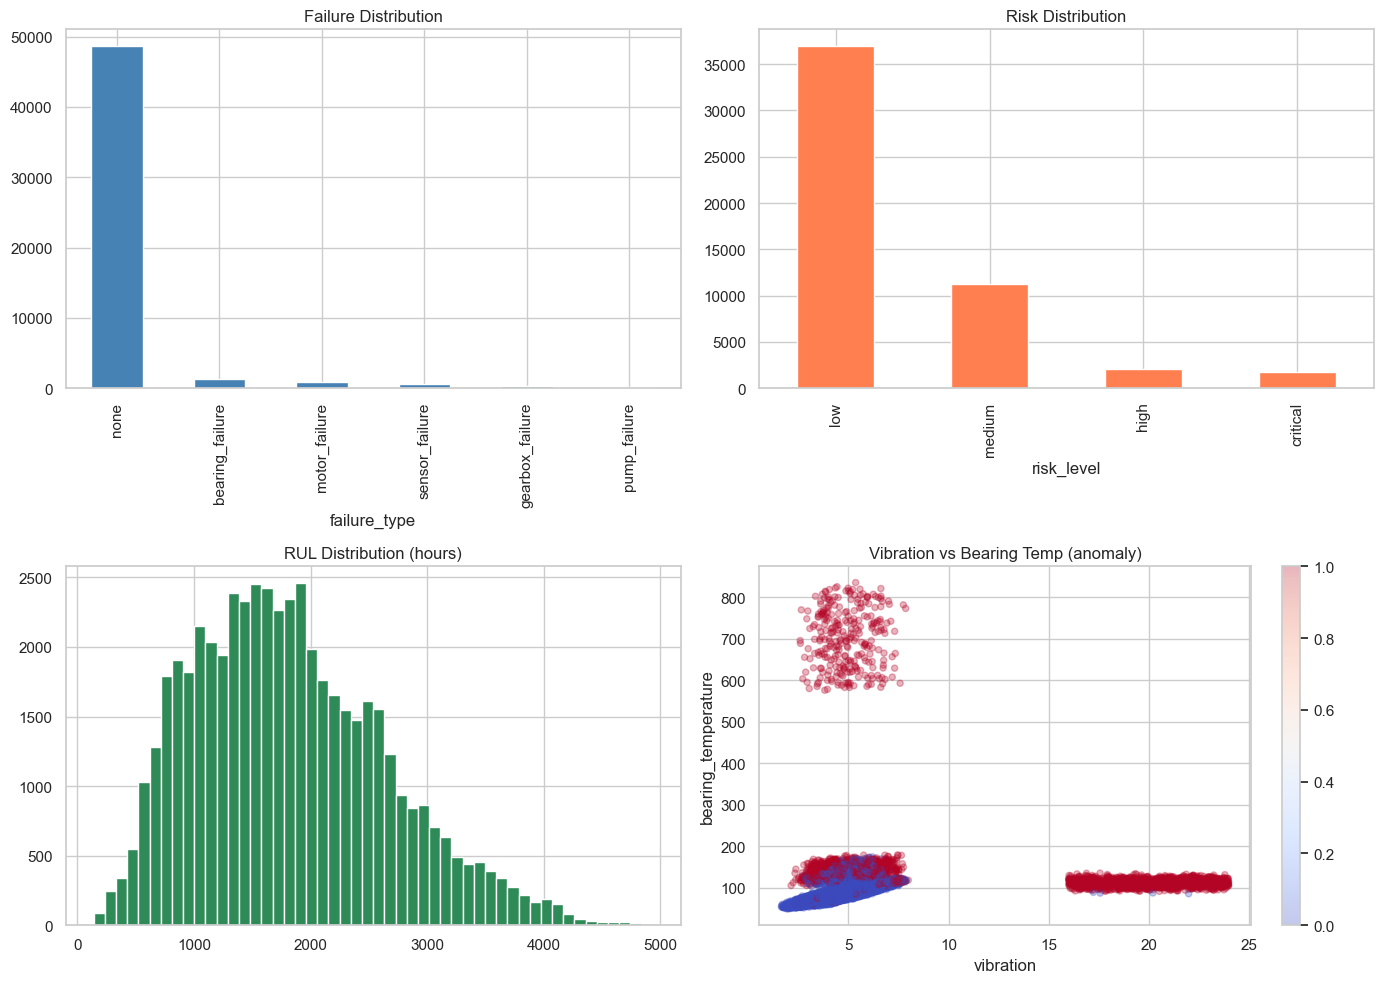

,f0,f1,f2,f3,f4,f5,f6,f7,target
0,0.0,0.656834,0.1,0.433681,0.977573,0.359364,0.162912,0.416043,0
1,0.0,0.652256,0.1,0.435130,0.977573,0.357884,0.173377,0.412855,0
2,0.0,0.645211,0.1,0.436576,0.977573,0.359256,0.163236,0.431412,0
3,0.0,0.649890,0.1,0.438020,0.977573,0.352475,0.167011,0.421257,0
4,0.0,0.643205,0.1,0.439460,0.977573,0.357993,0.170938,0.426902,0


In [2]:
# --- Data Engineering & EDA ---
master = pd.read_csv(MASTER / "industrial_master.csv", parse_dates=["timestamp"])
print(f"Master records: {len(master):,} | Assets: {master['equipment_id'].nunique()}")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
master["failure_type"].value_counts().plot(kind="bar", ax=axes[0,0], title="Failure Distribution", color="steelblue")
master["risk_level"].value_counts().plot(kind="bar", ax=axes[0,1], title="Risk Distribution", color="coral")
axes[1,0].hist(master["remaining_useful_life_hours"], bins=50, color="seagreen", edgecolor="white")
axes[1,0].set_title("RUL Distribution (hours)")
master.plot.scatter(x="vibration", y="bearing_temperature", c=master["is_anomaly"], cmap="coolwarm", alpha=0.3, ax=axes[1,1])
axes[1,1].set_title("Vibration vs Bearing Temp (anomaly)")
plt.tight_layout()
plt.savefig(DATASETS / MODEL_KEY / "eda_overview.png", dpi=120)
plt.show()

if TRAIN_CSV.exists():
    try:
        from IPython.display import display
        display(pd.read_csv(TRAIN_CSV).head())
    except ImportError:
        print(pd.read_csv(TRAIN_CSV).head())

## 3. Model Training & Evaluation

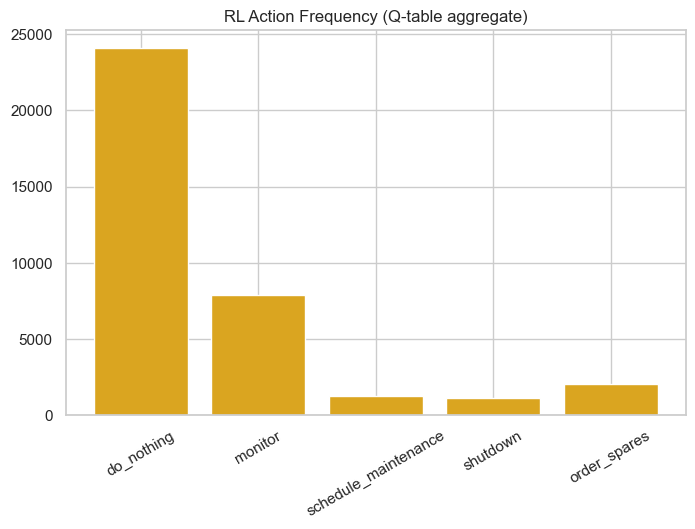

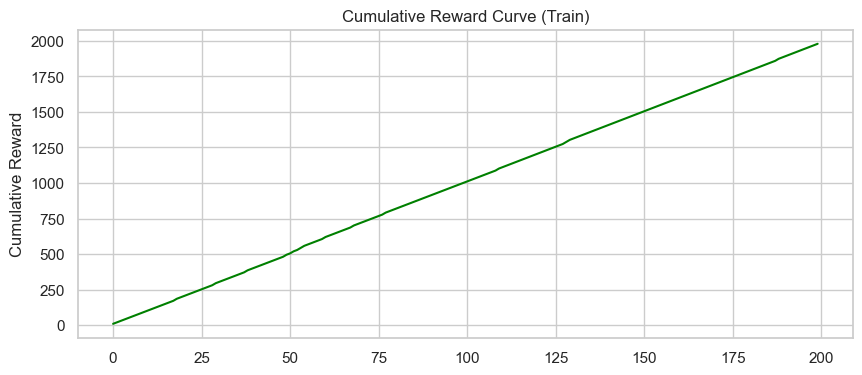

Mean reward: 10.09 | Cost saved estimate: 367394.1


['c:\\Users\\ASUS\\Downloads\\tata-steel-round -2\\industrial-agentic-maintenance-ai\\backend\\artifacts\\maintenance_rl.joblib']

In [3]:
import joblib

X_train, y_train = train_npz["X"], train_npz["y"]
rewards = train_npz.get("rewards", np.zeros(len(X_train)))
ACTIONS = ["do_nothing","monitor","schedule_maintenance","shutdown","order_spares"]

q = np.zeros((5, 5))
for row, action in zip(X_train, y_train):
    state = min(int(row[0] * 4), 4)
    q[state, action] += 1
policy = q.argmax(axis=1)

plt.figure(figsize=(8,5))
plt.bar(ACTIONS, q.sum(axis=0), color="goldenrod")
plt.xticks(rotation=30); plt.title("RL Action Frequency (Q-table aggregate)")
plt.savefig(DATASETS / MODEL_KEY / "action_distribution.png", dpi=120)
plt.show()

plt.figure(figsize=(10,4))
plt.plot(np.cumsum(rewards[:200]), color="green")
plt.title("Cumulative Reward Curve (Train)")
plt.ylabel("Cumulative Reward")
plt.savefig(DATASETS / MODEL_KEY / "reward_curve.png", dpi=120)
plt.show()

print(f"Mean reward: {rewards.mean():.2f} | Cost saved estimate: {rewards[rewards>0].sum():.1f}")
joblib.dump({"q_table": q, "policy": policy.tolist()}, ARTIFACTS / "maintenance_rl.joblib")

## 4. Pipeline Evaluation Metrics

In [4]:
metrics_path = EVAL / "metrics.json"
if metrics_path.exists():
    all_metrics = json.loads(metrics_path.read_text())
    print(json.dumps(all_metrics.get(MODEL_KEY, {}), indent=2))
else:
    print("Run: python scripts/generate_synthetic_data.py --skip-train  to generate metrics")

{
  "mean_reward_test": 10.23835563659668,
  "cost_saved_estimate": 79859.171875,
  "downtime_reduction_score": 0.9108974358974359,
  "actions": [
    "do_nothing",
    "monitor",
    "schedule_maintenance",
    "shutdown",
    "order_spares"
  ],
  "summary": "Reward=10.24"
}


## 5. Production Deployment

Artifact saved to `backend/artifacts/`. Restart API after retraining:
```bash
cd backend && uvicorn main:app --reload --port 8000
```